# Spontaneous Disentanglement from Many-Body Unitaries

In [1]:
# Import libraries
import numpy as np
from tqdm import tqdm

from disentanglement import *

# Set default plot parameters
plt.rcParams["font.size"] = 12
plt.rcParams["font.family"] = "Arial"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

In [2]:
def plot_states_on_bloch_sphere(phi0, phi1):
    fig, ax = plt.subplots(1, 1, subplot_kw={"projection": "3d"}, figsize=(2.5, 2.5), dpi=300)
    
    # Plot Bloch sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, color="gray", alpha=0.15)
        
    # Plot states for measurement outcome 0
    for i in range(phi0.shape[0]):
        x0 = 2 * np.real(phi0[i, 0] * np.conj(phi0[i, 1]))
        y0 = 2 * np.imag(phi0[i, 0] * np.conj(phi0[i, 1]))
        z0 = np.abs(phi0[i, 0])**2 - np.abs(phi0[i, 1])**2
        ax.scatter(x0, y0, z0, color="blue", alpha=0.5)
        
    # Plot states for measurement outcome 1
    for i in range(phi1.shape[0]):
        x1 = 2 * np.real(phi1[i, 0] * np.conj(phi1[i, 1]))
        y1 = 2 * np.imag(phi1[i, 0] * np.conj(phi1[i, 1]))
        z1 = np.abs(phi1[i, 0])**2 - np.abs(phi1[i, 1])**2
        ax.scatter(x1, y1, z1, color="red", alpha=0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    
    return fig, ax

## Plotting initial states on the Bloch sphere

Diagonalizing W0 and W1...
Elapsed time: 1.5833261013031006 seconds


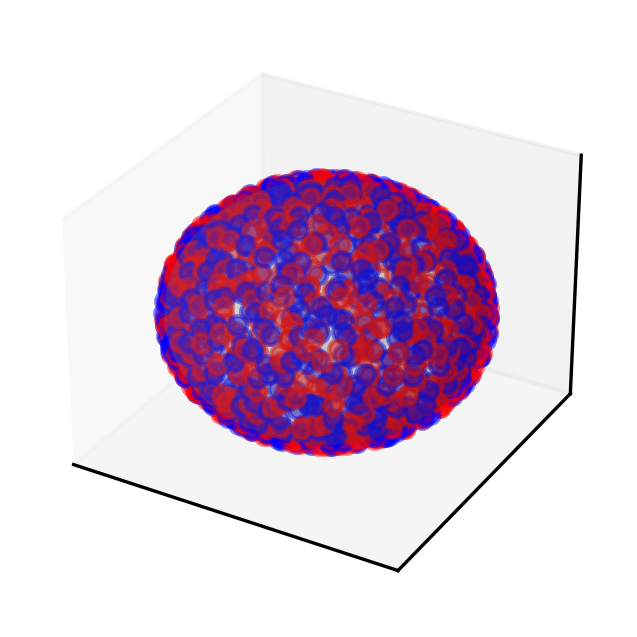

In [3]:
N = 10
D = 2 ** N

# Haar-random unitary
U_rand = generate_random_unitary(D)
analyzer_rand = DisentanglementAnalyzer(U_rand)
analyzer_rand.diagonalize_sublocks_product(verbose=True)
analyzer_rand.get_initial_qubit_states_from_eigenvalues()
fig, ax = plot_states_on_bloch_sphere(analyzer_rand.phi0, analyzer_rand.phi1)
plt.show()
fig.savefig("figures/bloch_haar_random.png", transparent=True, bbox_inches="tight")

Diagonalizing W0 and W1...
Elapsed time: 1.3093929290771484 seconds


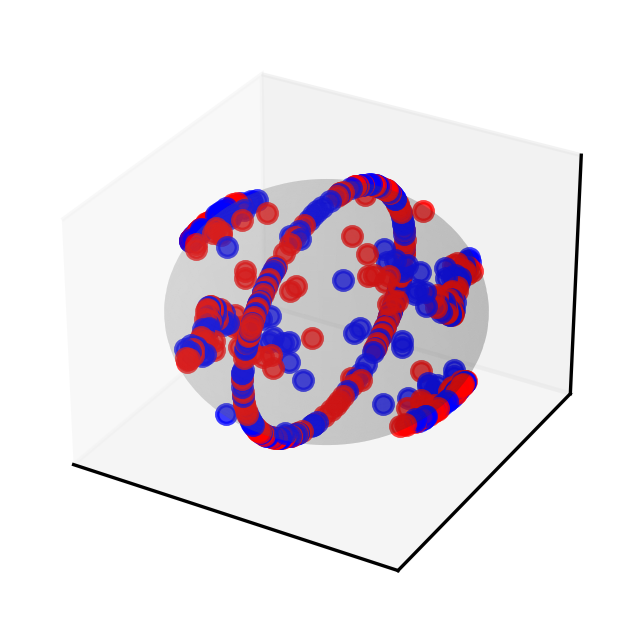

In [4]:
# 1D transverse field Ising (integrable)
H_int = generate_mixed_field_ising_hamiltonian(N, J=1.0, hx=1.3, hz=0.0)
U_int = generate_time_evolution_operator(H_int, t=-10)
analyzer_int = DisentanglementAnalyzer(U_int)
analyzer_int.diagonalize_sublocks_product(verbose=True)
analyzer_int.get_initial_qubit_states_from_eigenvalues()
fig, ax = plot_states_on_bloch_sphere(analyzer_int.phi0, analyzer_int.phi1)
plt.show()
fig.savefig("figures/bloch_ising_integrable.png", transparent=True, bbox_inches="tight")

Diagonalizing W0 and W1...
Elapsed time: 1.2532353401184082 seconds


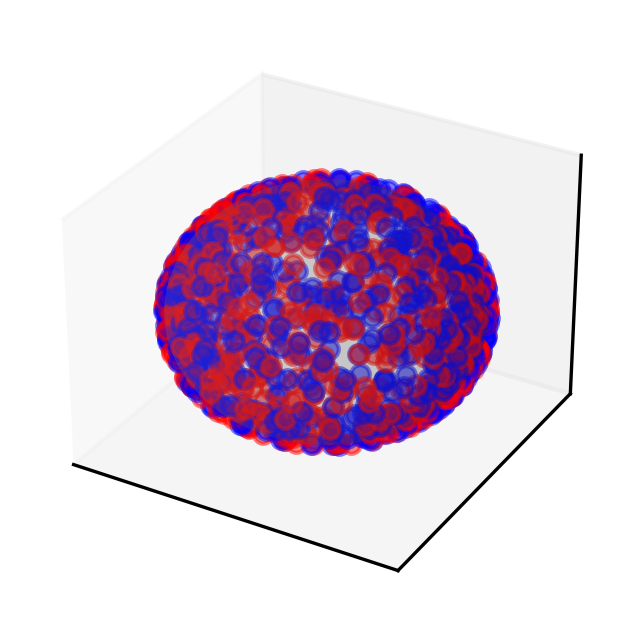

In [5]:
# 1D mixed field Ising (non-integrable)
H_nonint = generate_mixed_field_ising_hamiltonian(N, J=1.0, hx=1.3, hz=0.3)
U_nonint = generate_time_evolution_operator(H_nonint, t=-10)
analyzer_nonint = DisentanglementAnalyzer(U_nonint)
analyzer_nonint.diagonalize_sublocks_product(verbose=True)
analyzer_nonint.get_initial_qubit_states_from_eigenvalues()
fig, ax = plot_states_on_bloch_sphere(analyzer_nonint.phi0, analyzer_nonint.phi1)
plt.show()
fig.savefig("figures/bloch_ising_nonintegrable.png", transparent=True, bbox_inches="tight")

## Histograms of the z component

In [3]:
def plot_z_component_histogram(phi0, phi1, bins=10):
    z0 = np.abs(phi0[:, 0])**2 - np.abs(phi0[:, 1])**2
    z1 = np.abs(phi1[:, 0])**2 - np.abs(phi1[:, 1])**2
    
    fig, ax = plt.subplots(1, 1, figsize=(2, 1.5), dpi=300)
    ax.hist(z0, bins=bins, alpha=0.5, color="blue", density=True)
    ax.hist(z1, bins=bins, alpha=0.5, color="red", density=True)
    
    return fig, ax

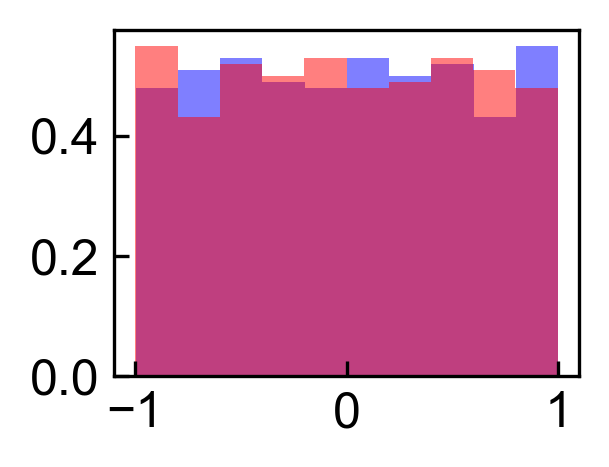

In [7]:
# Haar-random unitary
fig, ax = plot_z_component_histogram(analyzer_rand.phi0, analyzer_rand.phi1)
plt.show()
fig.savefig("figures/z_component_haar_random.svg", transparent=True, bbox_inches="tight")

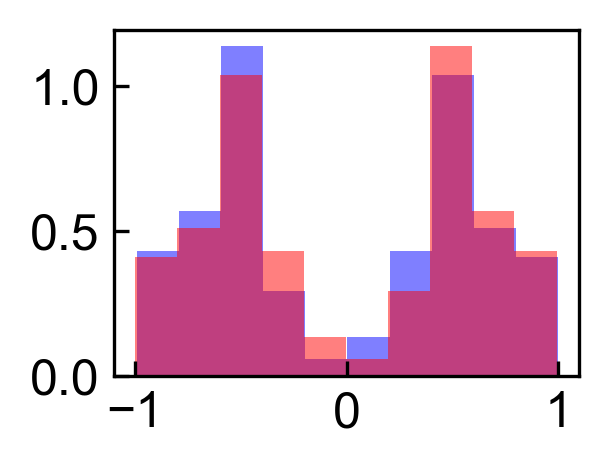

In [8]:
# 1D transverse field Ising (integrable)
fig, ax = plot_z_component_histogram(analyzer_int.phi0, analyzer_int.phi1)
plt.show()
fig.savefig("figures/z_component_ising_integrable.svg", transparent=True, bbox_inches="tight")

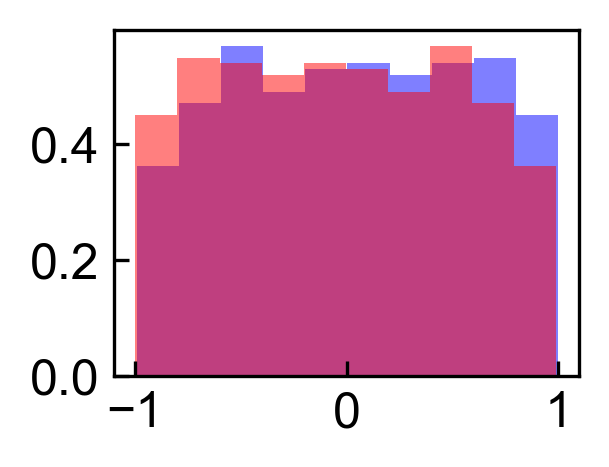

In [9]:
# 1D mixed field Ising (non-integrable)
fig, ax = plot_z_component_histogram(analyzer_nonint.phi0, analyzer_nonint.phi1)
plt.show()
fig.savefig("figures/z_component_ising_nonintegrable.svg", transparent=True, bbox_inches="tight")

## Replicating Born distribution

In [12]:
seed = 42
rng = np.random.default_rng(seed)

N = 8  # Number of qubits minus 1
D = 2**N

z = sample_from_born_distribution(D, seed=seed)
theta = rng.uniform(0, 2 * np.pi, D)
lambdas = get_eigvals_from_z_and_theta(z, theta)
U_born = generate_special_unitary_from_eigvals(lambdas)

analyzer = DisentanglementAnalyzer(U_born)
analyzer.diagonalize_sublocks_product(verbose=True)
analyzer.get_initial_qubit_states_from_eigenvalues()

Diagonalizing W0 and W1...
Elapsed time: 0.02097177505493164 seconds


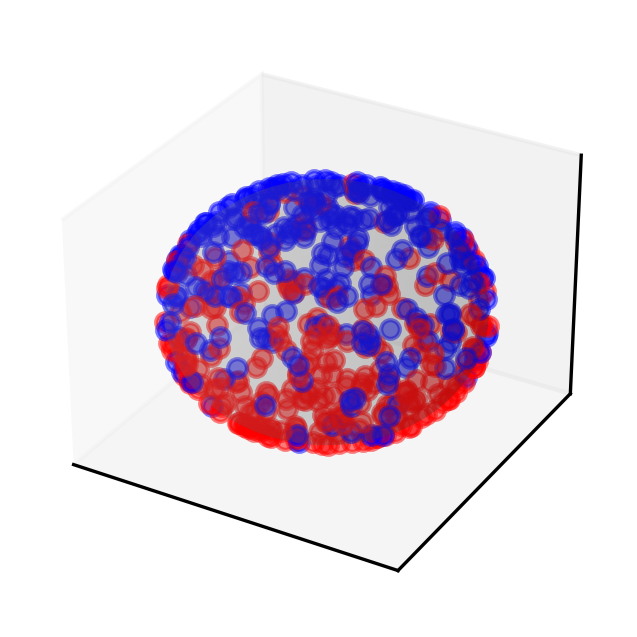

In [13]:
fig, ax = plot_states_on_bloch_sphere(analyzer.phi0, analyzer.phi1)
plt.show()

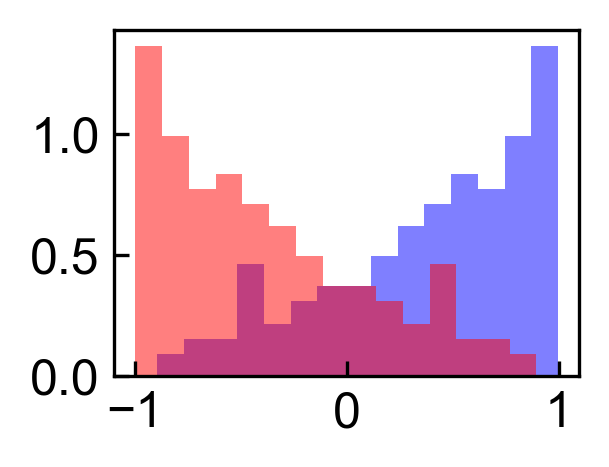

In [17]:
fig, ax = plot_z_component_histogram(analyzer.phi0, analyzer.phi1, bins=15)

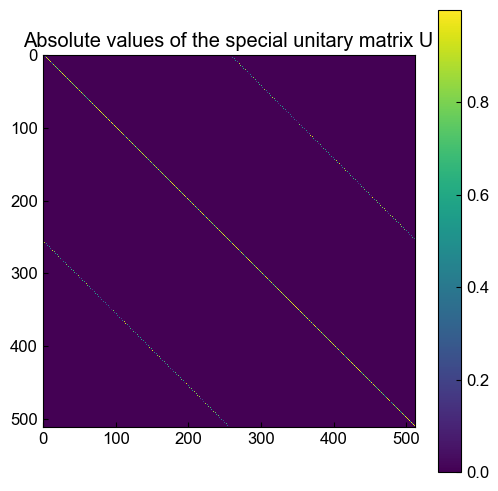

In [15]:
# Visualize unitary matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
im = ax.imshow(np.abs(U_born), cmap="viridis", interpolation="nearest")
ax.set_title("Absolute values of the special unitary matrix U")
plt.colorbar(im, ax=ax)
plt.show()

## Simulating time evolution of the special states

In [18]:
N_pixel = 5
N = 2 * N_pixel + 1  # Two pixels with N_pixel qubits each and one central qubit
D = 2 ** N

# Construct two-pixel Hamiltonian
Jx = 1.0
Jz = 2.0
H = generate_two_pixel_hamiltonian(N_pixel, Jx=Jx, Jz=Jz, disorder=True)
U = generate_time_evolution_operator(H, t=-100)

# Find special states
analyzer = DisentanglementAnalyzer(U)
analyzer.diagonalize_sublocks_product(verbose=True)
analyzer.get_initial_qubit_states_from_eigenvalues()

Diagonalizing W0 and W1...
Elapsed time: 9.879890203475952 seconds


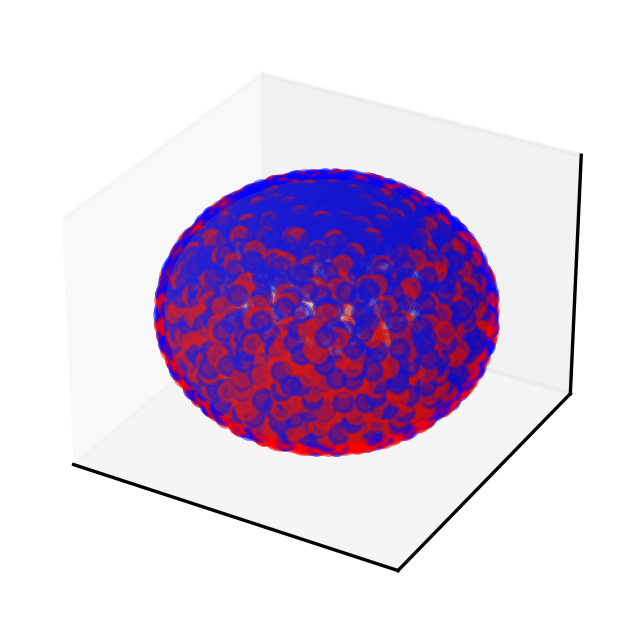

In [19]:
# Plot states on Bloch sphere
fig, ax = plot_states_on_bloch_sphere(analyzer.phi0, analyzer.phi1)
plt.show()

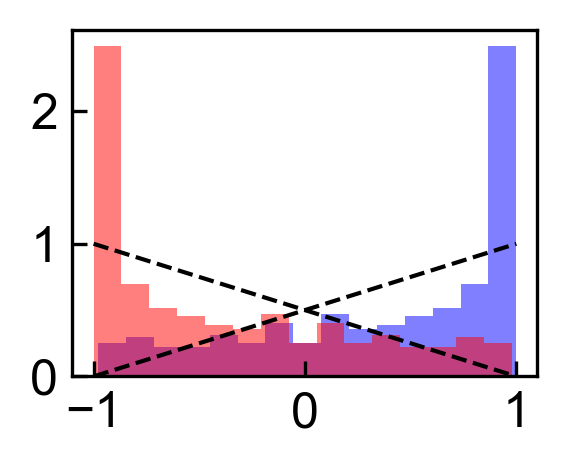

In [20]:
# Plot z-component histogram
fig, ax = plot_z_component_histogram(analyzer.phi0, analyzer.phi1, bins=15)
x = np.linspace(-1, 1, 1000)
y = (1 + x) / 2
ax.plot(x, y, "k--", lw=1)
ax.plot(x, 1 - y, "k--", lw=1)
plt.show()

In [21]:
# Diagonalize two-pixel Hamiltonian
t0 = time.time()
E, V = np.linalg.eigh(H)
t1 = time.time()
print(f"Diagonalization time: {t1 - t0:.2f} seconds")

Diagonalization time: 2.78 seconds


In [22]:
def compute_z_component_of_first_qubit(psi):
    D = psi.shape[0]
    return np.sum(np.abs(psi[:D // 2])**2) - np.sum(np.abs(psi[D // 2:])**2)

In [23]:
# Compute time evolution of special states
dt = 0.1
t = np.arange(0, 120 + dt, dt)
z0_t, z1_t = [], []
num_states_to_compute = 5
temp_psi0_t = np.zeros((num_states_to_compute,), dtype=np.complex128)
temp_psi1_t = np.zeros((num_states_to_compute,), dtype=np.complex128)

Udt = V @ np.diag(np.exp(-1j * E * dt)) @ V.conj().T
U00 = analyzer.U[:D // 2, :D // 2]
U11 = analyzer.U[D // 2:, D // 2:]

for i in range(num_states_to_compute):
    print(f"Computing time evolution for state {i + 1}/{num_states_to_compute}", end="\r")
    temp_psi0_t = np.kron(analyzer.phi0[i, :], U00 @ analyzer.V0[:, i])
    temp_psi1_t = np.kron(analyzer.phi1[i, :], U11 @ analyzer.V1[:, i])
    temp_psi0_t /= np.linalg.norm(temp_psi0_t)
    temp_psi1_t /= np.linalg.norm(temp_psi1_t)
    z0_t_i, z1_t_i = np.zeros((len(t),)), np.zeros((len(t),))
    for j in tqdm(range(len(t))):
        z0_t_i[j] = compute_z_component_of_first_qubit(temp_psi0_t)
        z1_t_i[j] = compute_z_component_of_first_qubit(temp_psi1_t)
        temp_psi0_t = Udt @ temp_psi0_t
        temp_psi1_t = Udt @ temp_psi1_t
    z0_t.append(z0_t_i)
    z1_t.append(z1_t_i)

100%|██████████| 1201/1201 [00:14<00:00, 82.81it/s]


100%|██████████| 1201/1201 [00:14<00:00, 81.89it/s]


100%|██████████| 1201/1201 [00:17<00:00, 70.59it/s]


100%|██████████| 1201/1201 [00:15<00:00, 77.46it/s]


100%|██████████| 1201/1201 [00:16<00:00, 72.49it/s]


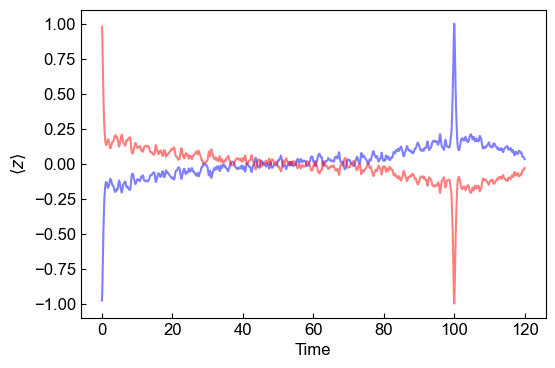

In [30]:
# Plot <z> vs time
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
for i in range(1):
    ax.plot(t, z0_t[i], color="blue", alpha=0.5)
    ax.plot(t, z1_t[i], color="red", alpha=0.5)
# ax.set_xlim(90, 110)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle z \rangle$")
plt.show()

In [97]:
analyzer.phi0[-1]

array([1.00000000e+00+0.00000000e+00j, 3.15574316e-16+2.24932471e-16j])